# 📊 Tầng 3c: Free Text Analysis — Word Cloud & Keywords

**Mục tiêu:** Phân tích câu trả lời tự do, trực quan hóa qua Word Cloud  
và thống kê Top Keywords theo từng câu hỏi.

**Input:** `tagged_free_text.csv`  
**Output:** Biểu đồ lưu vào `output/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import re
from pathlib import Path
from collections import Counter
from wordcloud import WordCloud

# ══════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════

os.makedirs("output/2_multiple_answers_freetext", exist_ok=True)

matplotlib.rcParams["font.family"] = "Arial"
matplotlib.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", palette="muted", font="Arial")

# Font path cho WordCloud (cần font hỗ trợ tiếng Việt)
# Windows: Arial Unicode hoặc Segoe UI
FONT_PATH = r"C:\Windows\Fonts\arial.ttf"
if not Path(FONT_PATH).exists():
    FONT_PATH = r"C:\Windows\Fonts\segoeui.ttf"
if not Path(FONT_PATH).exists():
    FONT_PATH = None  # Fallback to default
    print("⚠️  Không tìm thấy font tiếng Việt, WordCloud có thể không hiển thị đúng dấu")

INPUT_FILE = "tagged_free_text.csv"
assert Path(INPUT_FILE).exists(), f"❌ Chưa có {INPUT_FILE}!"
df = pd.read_csv(INPUT_FILE, encoding="utf-8-sig")
print(f"✅ Đọc {INPUT_FILE}: {len(df)} responses từ {df['question'].nunique()} câu hỏi")
print(f"📋 Columns: {list(df.columns)}")

✅ Đọc tagged_free_text.csv: 47 responses từ 6 câu hỏi
📋 Columns: ['question', 'response_id', 'response_raw', 'response_clean', 'tokens', 'token_count', 'tags']


In [2]:
# ══════════════════════════════════════════════════════════
# HÀM TIỆN ÍCH
# ══════════════════════════════════════════════════════════

def make_safe_filename(text, max_len=40):
    """Chuyển text câu hỏi → tên file an toàn."""
    safe = re.sub(r"[^\w\s-]", "", text, flags=re.UNICODE)
    safe = re.sub(r"\s+", "_", safe.strip())
    return safe[:max_len].rstrip("_").lower()


def plot_top_keywords(tokens_series, title, filename,
                      top_n=15, figsize=(10, 6)):
    """
    Bar chart ngang cho Top N từ khóa.
    tokens_series: pd.Series chứa chuỗi tokens phân cách bởi ' | '
    """
    # Tách tokens từ string format
    all_tokens = (
        tokens_series
        .dropna()
        .str.split(" | ", regex=False)
        .explode()
        .str.strip()
    )
    all_tokens = all_tokens[all_tokens.str.len() > 1]

    if all_tokens.empty:
        print(f"   ⚠️  Không có tokens cho: {title}")
        return

    freq = all_tokens.value_counts().head(top_n)

    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette("YlOrRd_r", len(freq))
    ax.barh(range(len(freq)), freq.values, color=colors,
            edgecolor="white", linewidth=0.8)

    ax.set_yticks(range(len(freq)))
    # Thay thế dấu gạch dưới thành dấu cách để hiển thị từ ghép tự nhiên
    clean_labels = [str(label).replace("_", " ") for label in freq.index]
    ax.set_yticklabels(clean_labels, fontsize=10)
    ax.invert_yaxis()

    for i, val in enumerate(freq.values):
        ax.text(val + freq.max() * 0.02, i, str(val),
                va="center", fontsize=10, fontweight="bold")

    ax.set_xlabel("Tần suất", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.set_xlim(0, freq.max() * 1.2)
    sns.despine(left=True)

    plt.tight_layout()
    plt.savefig(f"output/2_multiple_answers_freetext/{filename}", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"   💾 Saved: output/2_multiple_answers_freetext/{filename}")


def plot_wordcloud(text_series, title, filename, figsize=(12, 6)):
    """
    Vẽ Word Cloud từ chuỗi text đã chuẩn hóa.
    """
    combined_text = " ".join(text_series.dropna().values)

    if not combined_text.strip():
        print(f"   ⚠️  Không có text cho WordCloud: {title}")
        return

    wc_kwargs = {
        "width": 1200,
        "height": 600,
        "background_color": "white",
        "max_words": 80,
        "colormap": "viridis",
        "contour_width": 2,
        "contour_color": "#2C3E50",
        "min_font_size": 10,
        "max_font_size": 100,
        "prefer_horizontal": 0.7,
        "relative_scaling": 0.6,
    }
    if FONT_PATH:
        wc_kwargs["font_path"] = FONT_PATH

    wc = WordCloud(**wc_kwargs).generate(combined_text)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)

    plt.tight_layout()
    plt.savefig(f"output/2_multiple_answers_freetext/{filename}", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"   💾 Saved: output/2_multiple_answers_freetext/{filename}")


def plot_tag_distribution(tags_series, title, filename, figsize=(10, 5)):
    """
    Bar chart cho phân bố tags.
    """
    all_tags = (
        tags_series
        .dropna()
        .str.split(", ", regex=False)
        .explode()
        .str.strip()
    )
    freq = all_tags.value_counts()

    fig, ax = plt.subplots(figsize=figsize)
    colors = sns.color_palette("Set2", len(freq))
    bars = ax.bar(range(len(freq)), freq.values, color=colors,
                  edgecolor="white", linewidth=0.8)

    ax.set_xticks(range(len(freq)))
    ax.set_xticklabels(freq.index, rotation=35, ha="right", fontsize=9)

    for i, val in enumerate(freq.values):
        ax.text(i, val + freq.max() * 0.02, str(val),
                ha="center", fontsize=10, fontweight="bold")

    ax.set_ylabel("Số lần xuất hiện", fontsize=10)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_ylim(0, freq.max() * 1.15)
    sns.despine()

    plt.tight_layout()
    plt.savefig(f"output/2_multiple_answers_freetext/{filename}", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"   💾 Saved: output/2_multiple_answers_freetext/{filename}")

print("✅ Các hàm tiện ích đã sẵn sàng")

✅ Các hàm tiện ích đã sẵn sàng


---
## 📌 Phần A — Tổng quan Tags (tất cả câu hỏi)

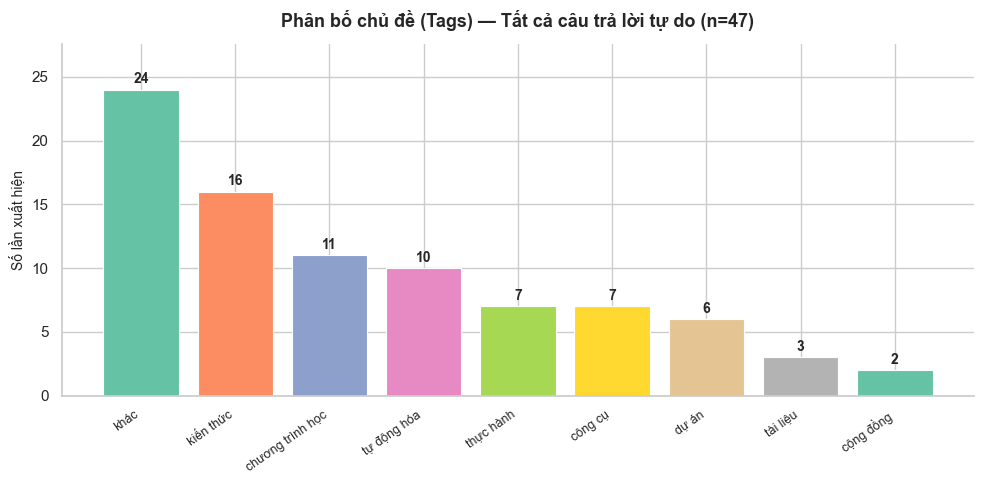

   💾 Saved: output/2_multiple_answers_freetext/freetext_tags_overall.png


In [3]:
# ── A1: Phân bố tags tổng thể ────────────────────────
plot_tag_distribution(df["tags"],
                      title=f"Phân bố chủ đề (Tags) — Tất cả câu trả lời tự do (n={len(df)})",
                      filename="freetext_tags_overall.png")

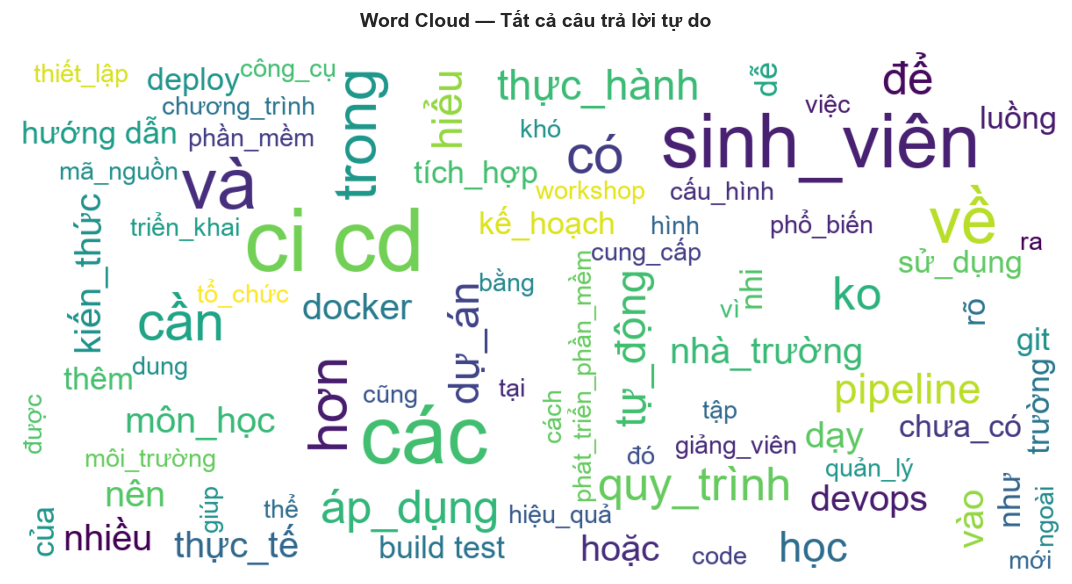

   💾 Saved: output/2_multiple_answers_freetext/wordcloud_overall.png


In [4]:
# ── A2: Word Cloud tổng thể ──────────────────────────
plot_wordcloud(df["response_clean"],
               title="Word Cloud — Tất cả câu trả lời tự do",
               filename="wordcloud_overall.png")

---
## 📌 Phần B — Phân tích theo từng câu hỏi

📋 Phân tích 6 câu hỏi:

────────────────────────────────────────────────────────────
  Q1. Theo bạn, điều gì cần cải thiện nhất ở các công cụ CI/CD hiện nay tại Việt Nam?
      (14 responses)
────────────────────────────────────────────────────────────


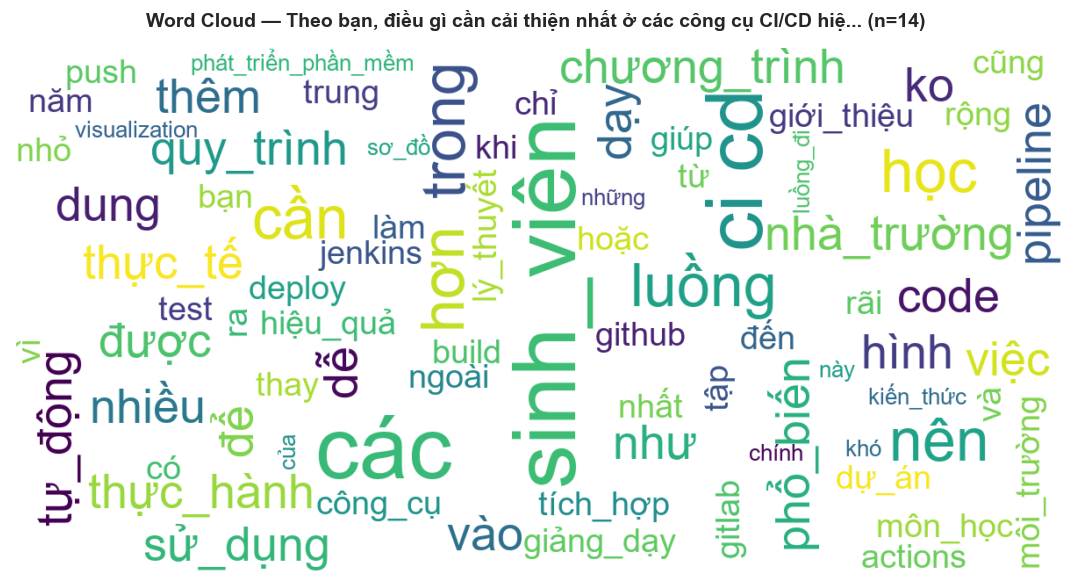

   💾 Saved: output/2_multiple_answers_freetext/wordcloud_theo_bạn_điều_gì_cần_cải_thiện_nhất_ở_cá.png


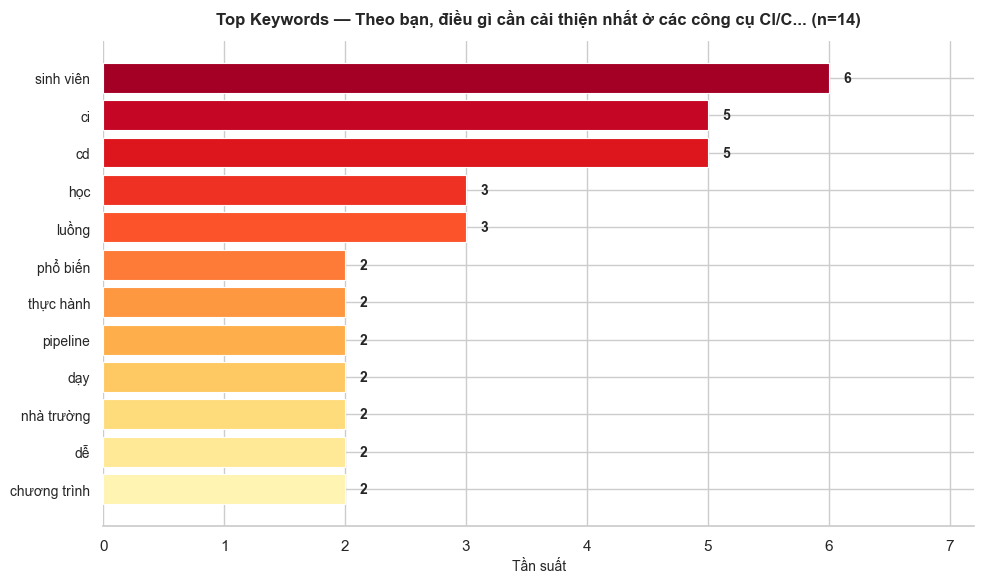

   💾 Saved: output/2_multiple_answers_freetext/keywords_theo_bạn_điều_gì_cần_cải_thiện_nhất_ở_cá.png

────────────────────────────────────────────────────────────
  Q2. Bạn có đề xuất nào để thúc đẩy áp dụng CI/CD hiệu quả hơn?
      (13 responses)
────────────────────────────────────────────────────────────


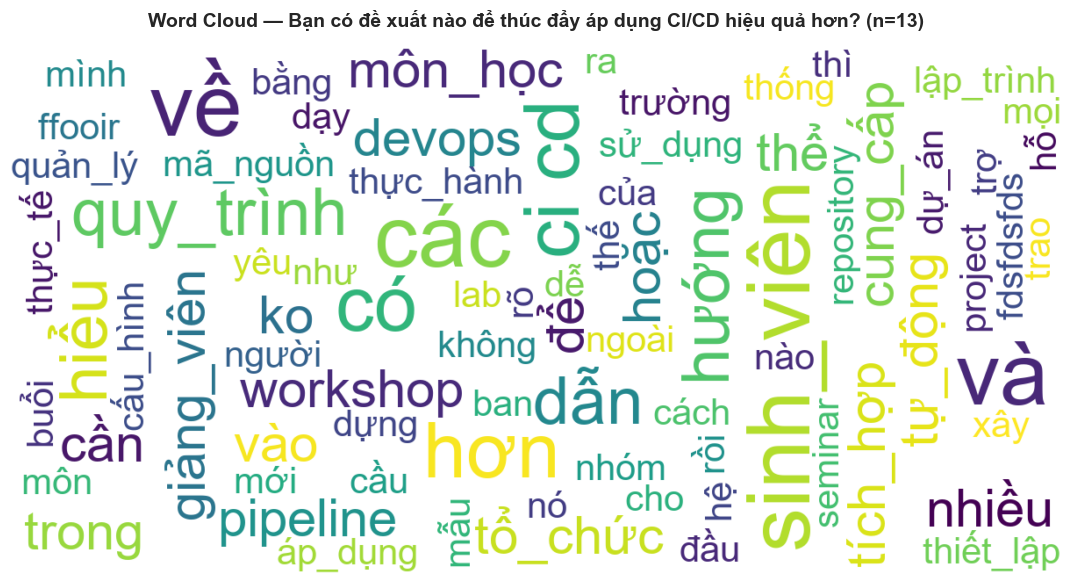

   💾 Saved: output/2_multiple_answers_freetext/wordcloud_bạn_có_đề_xuất_nào_để_thúc_đẩy_áp_dụng_c.png


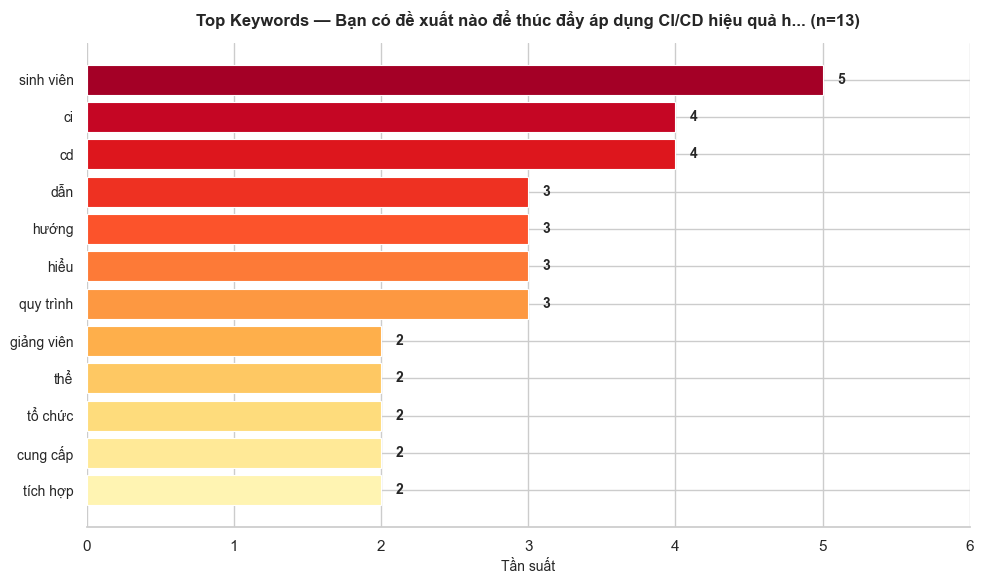

   💾 Saved: output/2_multiple_answers_freetext/keywords_bạn_có_đề_xuất_nào_để_thúc_đẩy_áp_dụng_c.png

────────────────────────────────────────────────────────────
  Q3. Những trang bị mà sinh viên cần để áp dụng CI/CD hiệu quả hơn là gì?
      (12 responses)
────────────────────────────────────────────────────────────


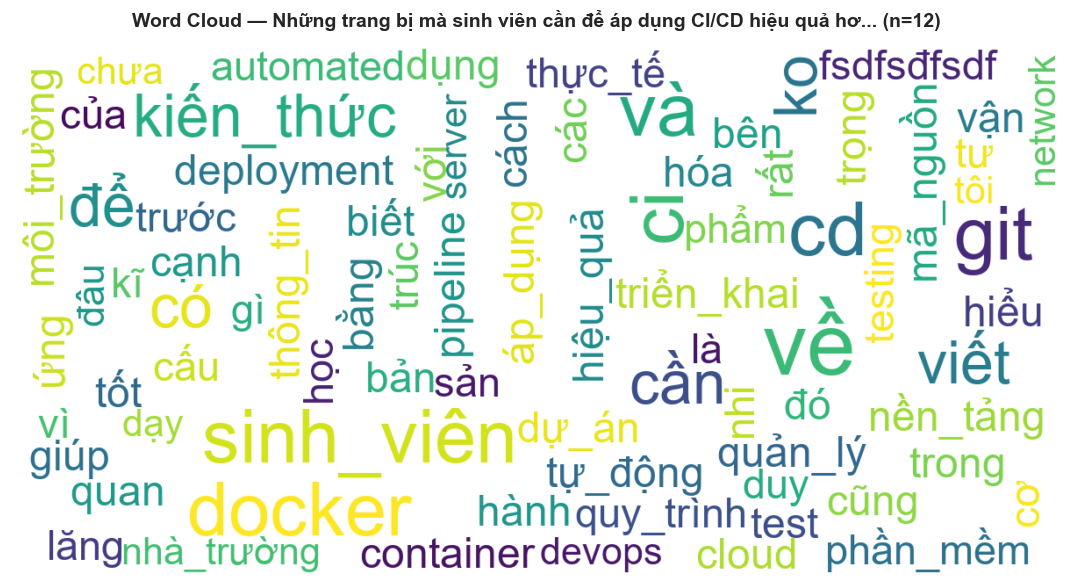

   💾 Saved: output/2_multiple_answers_freetext/wordcloud_những_trang_bị_mà_sinh_viên_cần_để_áp_dụ.png


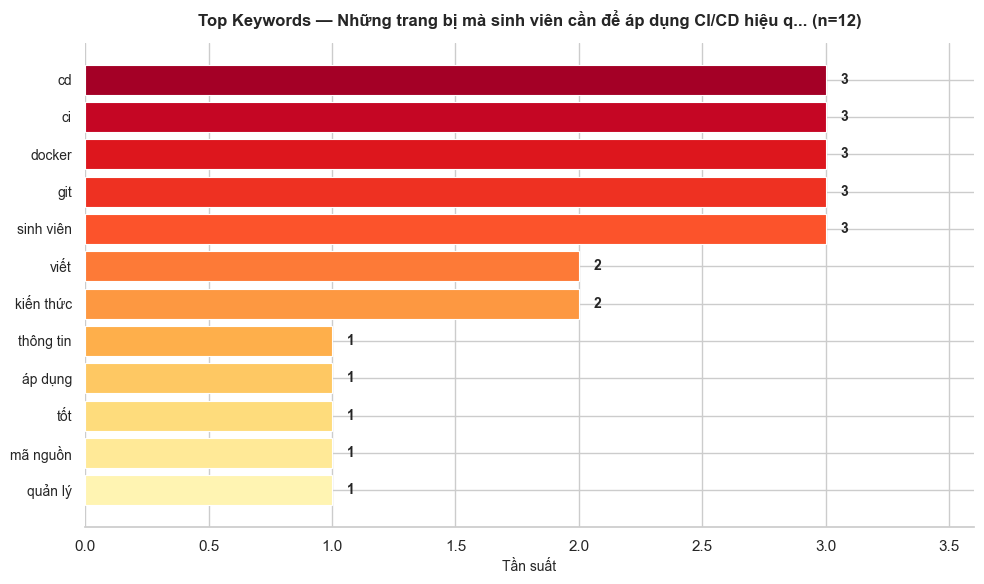

   💾 Saved: output/2_multiple_answers_freetext/keywords_những_trang_bị_mà_sinh_viên_cần_để_áp_dụ.png

────────────────────────────────────────────────────────────
  Q4. Bạn có dự định học hoặc áp dụng CI/CD trong thời gian tới không?
      (3 responses)
────────────────────────────────────────────────────────────


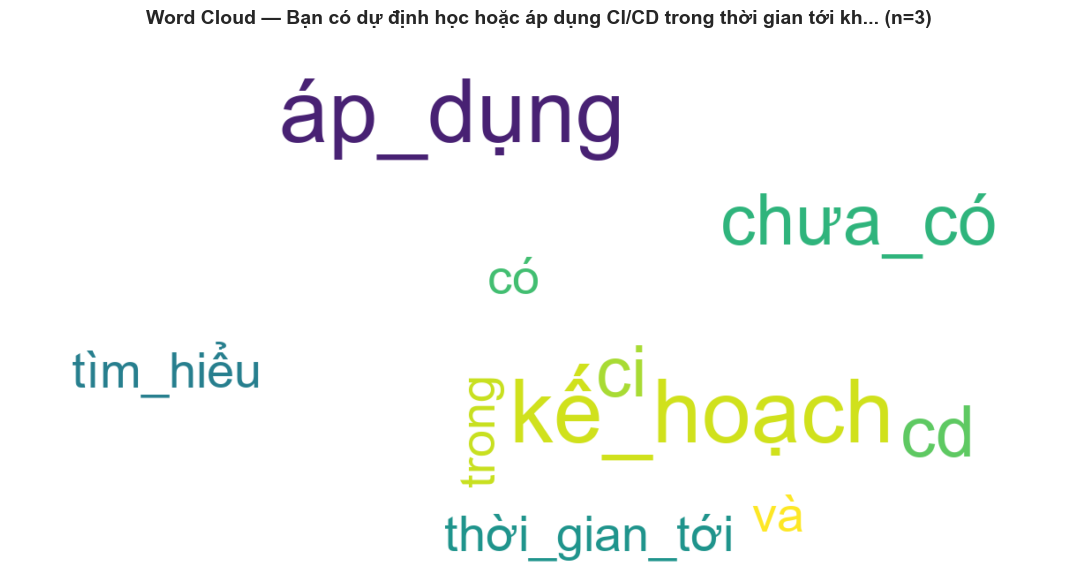

   💾 Saved: output/2_multiple_answers_freetext/wordcloud_bạn_có_dự_định_học_hoặc_áp_dụng_cicd_tro.png


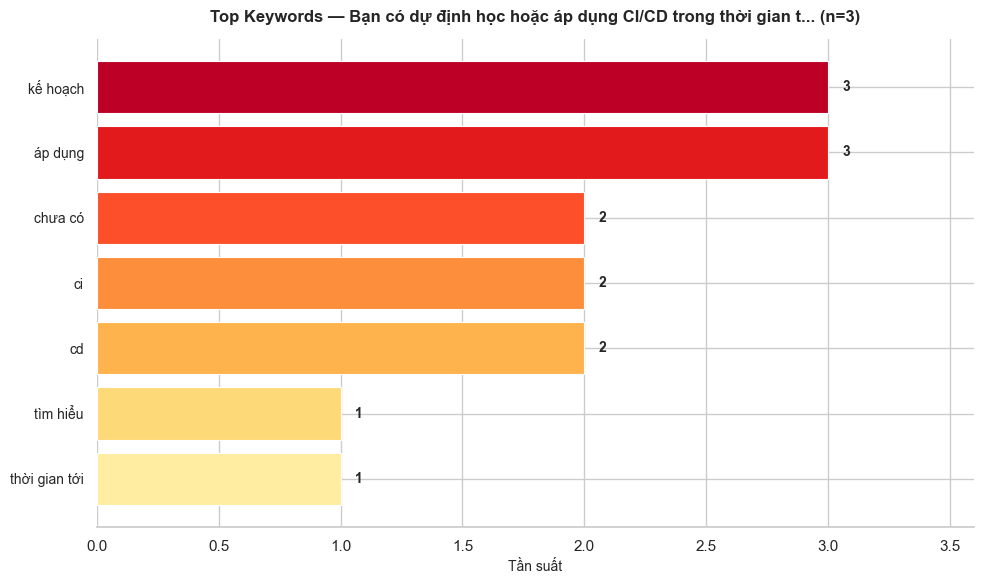

   💾 Saved: output/2_multiple_answers_freetext/keywords_bạn_có_dự_định_học_hoặc_áp_dụng_cicd_tro.png

────────────────────────────────────────────────────────────
  Q5. Theo bạn, rào cản lớn nhất khiến sinh viên chưa áp dụng CI/CD là gì?
      (3 responses)
────────────────────────────────────────────────────────────


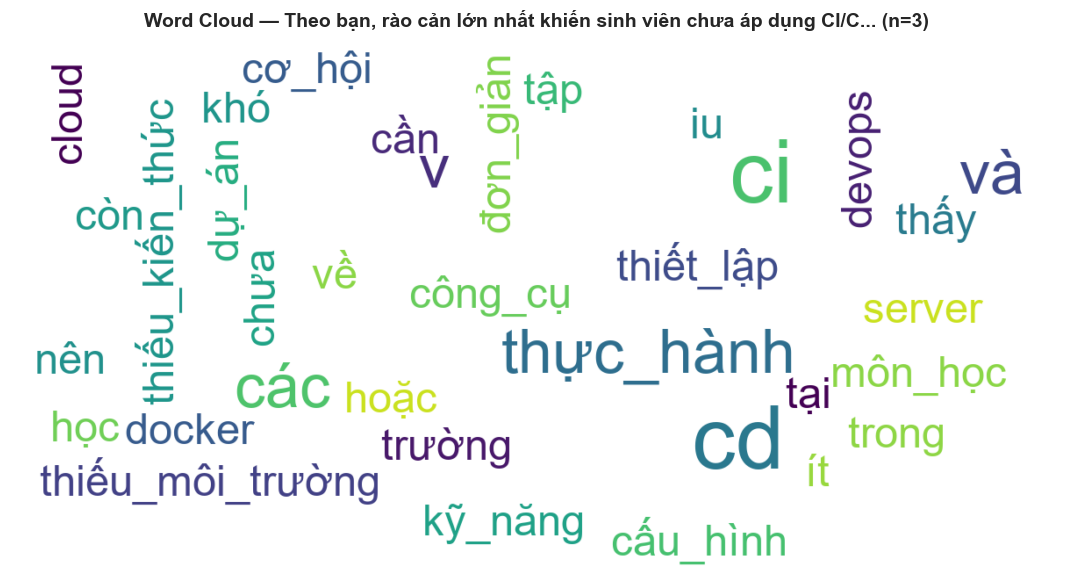

   💾 Saved: output/2_multiple_answers_freetext/wordcloud_theo_bạn_rào_cản_lớn_nhất_khiến_sinh_viê.png


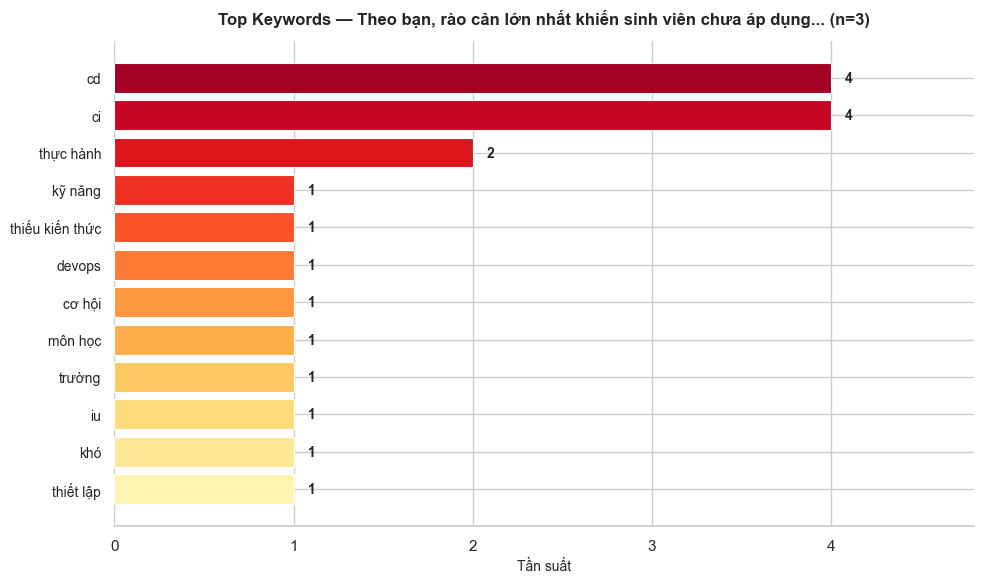

   💾 Saved: output/2_multiple_answers_freetext/keywords_theo_bạn_rào_cản_lớn_nhất_khiến_sinh_viê.png

────────────────────────────────────────────────────────────
  Q6. Bạn mong đợi điều gì nhất nếu CI/CD được đưa vào học tập/dự án thực tế?
      (2 responses)
────────────────────────────────────────────────────────────


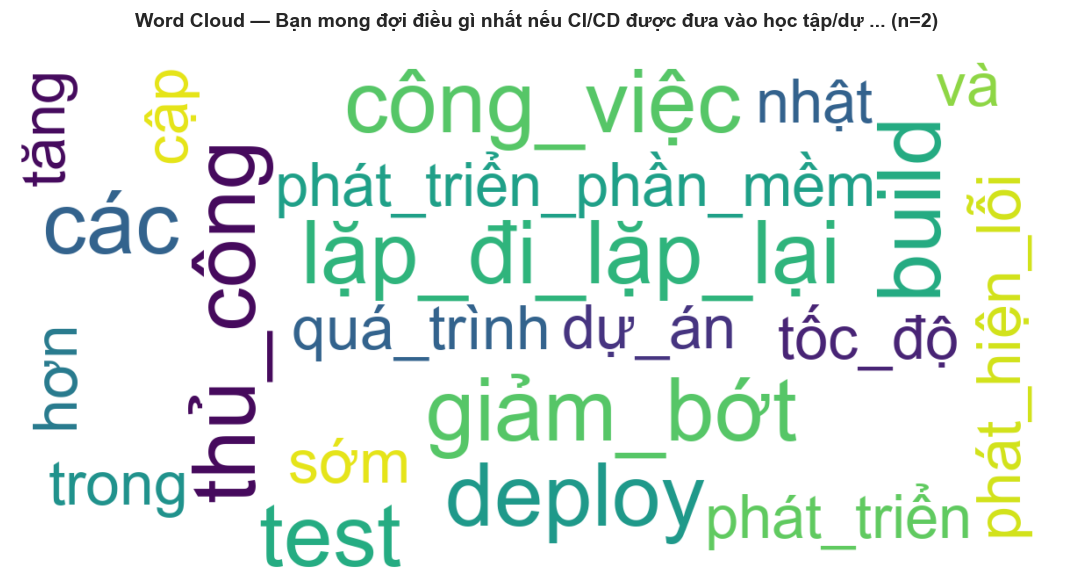

   💾 Saved: output/2_multiple_answers_freetext/wordcloud_bạn_mong_đợi_điều_gì_nhất_nếu_cicd_được.png


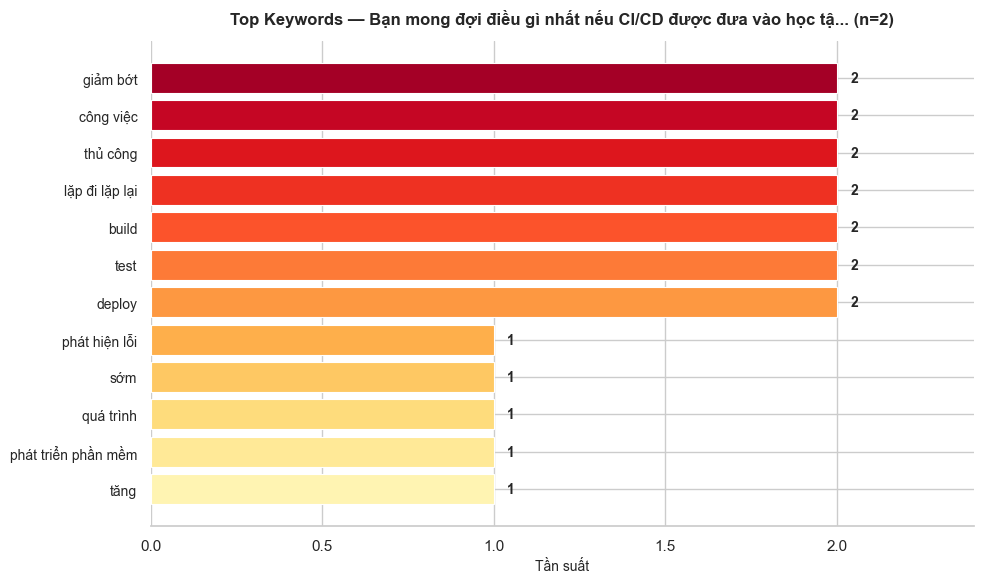

   💾 Saved: output/2_multiple_answers_freetext/keywords_bạn_mong_đợi_điều_gì_nhất_nếu_cicd_được.png



In [5]:
# ══════════════════════════════════════════════════════════
# Tự động tạo WordCloud + Top Keywords cho TỪNG câu hỏi
# ══════════════════════════════════════════════════════════

questions = df["question"].unique()
print(f"📋 Phân tích {len(questions)} câu hỏi:\n")

for idx, question in enumerate(questions, 1):
    mask = df["question"] == question
    df_q = df[mask]
    n_resp = len(df_q)
    safe_name = make_safe_filename(question)

    print(f"{'─'*60}")
    print(f"  Q{idx}. {question}")
    print(f"      ({n_resp} responses)")
    print(f"{'─'*60}")

    # Word Cloud cho câu hỏi này
    plot_wordcloud(
        df_q["response_clean"],
        title=f"Word Cloud — {question[:60]}{'...' if len(question) > 60 else ''} (n={n_resp})",
        filename=f"wordcloud_{safe_name}.png",
    )

    # Top Keywords cho câu hỏi này
    plot_top_keywords(
        df_q["tokens"],
        title=f"Top Keywords — {question[:55]}{'...' if len(question) > 55 else ''} (n={n_resp})",
        filename=f"keywords_{safe_name}.png",
        top_n=12,
    )
    print()

---
## 📌 Phần C — Tags theo từng câu hỏi

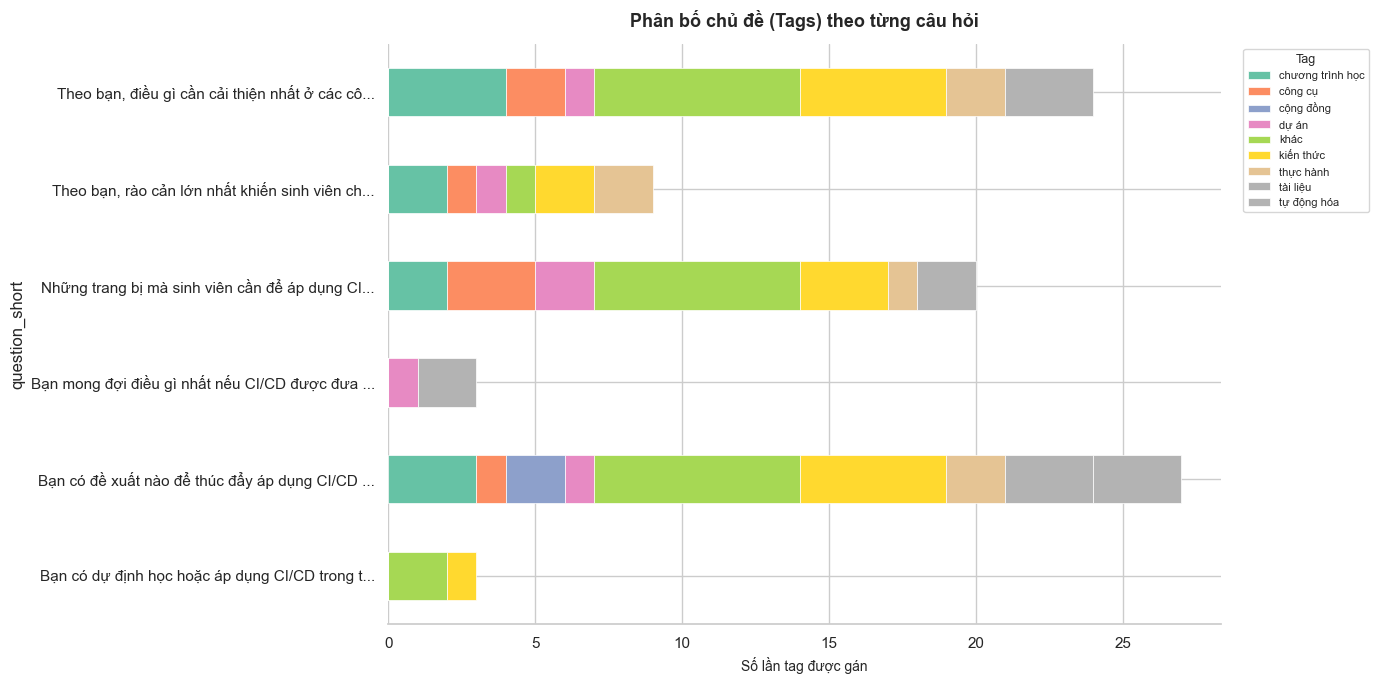

   💾 Saved: output/2_multiple_answers_freetext/freetext_tags_by_question.png


In [6]:
# ══════════════════════════════════════════════════════════
# Stacked Bar: phân bố tags THEO từng câu hỏi
# ══════════════════════════════════════════════════════════

# Explode tags để tạo bảng crosstab
df_exploded = df.copy()
df_exploded["tag_list"] = df_exploded["tags"].str.split(", ")
df_exploded = df_exploded.explode("tag_list")

# Short question labels
q_short_map = {}
for q in df["question"].unique():
    short = q[:45] + "..." if len(q) > 45 else q
    q_short_map[q] = short

df_exploded["question_short"] = df_exploded["question"].map(q_short_map)

# Crosstab
ct = pd.crosstab(df_exploded["question_short"], df_exploded["tag_list"])

# Stacked bar
fig, ax = plt.subplots(figsize=(14, 7))
ct.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    colormap="Set2",
    edgecolor="white",
    linewidth=0.5,
)

ax.set_xlabel("Số lần tag được gán", fontsize=10)
ax.set_title("Phân bố chủ đề (Tags) theo từng câu hỏi",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(title="Tag", bbox_to_anchor=(1.02, 1), loc="upper left",
          fontsize=8, title_fontsize=9)
sns.despine(left=True)

plt.tight_layout()
plt.savefig("output/2_multiple_answers_freetext/freetext_tags_by_question.png", bbox_inches="tight", dpi=150)
plt.show()
print("   💾 Saved: output/2_multiple_answers_freetext/freetext_tags_by_question.png")

---
## 📌 Phần D — Bảng tóm tắt toàn bộ responses

In [7]:
# ══════════════════════════════════════════════════════════
# Bảng tổng hợp: mỗi câu hỏi - số responses, top tags, top keywords
# ══════════════════════════════════════════════════════════

summary_rows = []
for question in df["question"].unique():
    mask = df["question"] == question
    df_q = df[mask]

    # Top 3 tags
    tags_exploded = df_q["tags"].str.split(", ").explode()
    top_tags = tags_exploded.value_counts().head(3).index.tolist()

    # Top 5 keywords
    tokens_all = df_q["tokens"].dropna().str.split(" | ", regex=False).explode().str.strip()
    tokens_all = tokens_all[tokens_all.str.len() > 1]
    top_kw = tokens_all.value_counts().head(5).index.tolist()

    summary_rows.append({
        "Câu hỏi": question[:60] + ("..." if len(question) > 60 else ""),
        "N": len(df_q),
        "Top Tags": ", ".join(top_tags),
        "Top Keywords": ", ".join(top_kw),
    })

summary_df = pd.DataFrame(summary_rows)
print("📊 BẢNG TÓM TẮT PHÂN TÍCH CÂU HỎI MỞ:")
summary_df

📊 BẢNG TÓM TẮT PHÂN TÍCH CÂU HỎI MỞ:


,Câu hỏi,N,Top Tags,Top Keywords
0,"Theo bạn, điều gì cần cải thiện nhất ở các côn...",14,"khác, kiến thức, chương trình học","sinh_viên, ci, cd, học, luồng"
1,Bạn có đề xuất nào để thúc đẩy áp dụng CI/CD h...,13,"khác, kiến thức, chương trình học","sinh_viên, ci, cd, dẫn, hướng"
2,Những trang bị mà sinh viên cần để áp dụng CI/...,12,"khác, kiến thức, công cụ","cd, ci, docker, git, sinh_viên"
3,Bạn có dự định học hoặc áp dụng CI/CD trong th...,3,"khác, kiến thức","kế_hoạch, áp_dụng, chưa_có, ci, cd"
4,"Theo bạn, rào cản lớn nhất khiến sinh viên chư...",3,"thực hành, chương trình học, kiến thức","cd, ci, thực_hành, kỹ_năng, thiếu_kiến_thức"
5,Bạn mong đợi điều gì nhất nếu CI/CD được đưa v...,2,"tự động hóa, dự án","giảm_bớt, công_việc, thủ_công, lặp_đi_lặp_lại,..."


In [8]:
# ══════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════

output_files = sorted([f for f in os.listdir("output/2_multiple_answers_freetext") if f.endswith(".png")])
my_files = [f for f in output_files if any(
    f.startswith(p) for p in ["wordcloud_", "keywords_", "freetext_"]
)]
print(f"\n{'═'*50}")
print(f"✅ HOÀN TẤT: 2c_free_text_analysis")
print(f"   Biểu đồ mới tạo: {len(my_files)} file")
for f in my_files:
    size_kb = os.path.getsize(f'output/2_multiple_answers_freetext/{f}') / 1024
    print(f"   📈 {f} ({size_kb:.0f} KB)")
print(f"   Tổng file trong output/2_multiple_answers_freetext/: {len(output_files)}")
print(f"{'═'*50}")


══════════════════════════════════════════════════
✅ HOÀN TẤT: 2c_free_text_analysis
   Biểu đồ mới tạo: 21 file
   📈 freetext_tags_by_question.png (88 KB)
   📈 freetext_tags_overall.png (51 KB)
   📈 keywords_bạn_có_dự_định_học_hoặc_áp_dụng_cicd_tro.png (38 KB)
   📈 keywords_bạn_có_đề_xuất_nào_để_các_trường_đại_học.png (44 KB)
   📈 keywords_bạn_có_đề_xuất_nào_để_thúc_đẩy_áp_dụng_c.png (47 KB)
   📈 keywords_bạn_mong_đợi_điều_gì_nhất_nếu_cicd_được.png (50 KB)
   📈 keywords_những_trang_bị_mà_sinh_viên_cần_để_áp_dụ.png (46 KB)
   📈 keywords_theo_bạn_rào_cản_lớn_nhất_khiến_sinh_viê.png (43 KB)
   📈 keywords_theo_bạn_sinh_viên_cần_được_trang_bị_thê.png (44 KB)
   📈 keywords_theo_bạn_điều_gì_cần_cải_thiện_nhất_ở_cá.png (47 KB)
   📈 keywords_theo_bạn_điều_gì_cần_được_cải_thiện_để_s.png (44 KB)
   📈 wordcloud_bạn_có_dự_định_học_hoặc_áp_dụng_cicd_tro.png (122 KB)
   📈 wordcloud_bạn_có_đề_xuất_nào_để_các_trường_đại_học.png (401 KB)
   📈 wordcloud_bạn_có_đề_xuất_nào_để_thúc_đẩy_áp_dụng_c.png (524